# Remaining Useful Life (RUL) Analysis

## Objective

The purpose of this notebook is to analyze the target variable used for Remaining Useful Life prediction.

Unlike the previous notebooks, which focused on the input features, this notebook investigates the characteristics of the prediction target.

The analysis aims to answer the following questions:

- How is the RUL distributed?
- Is the target balanced?
- How does RUL evolve during an engine's lifetime?
- Should RUL be capped before model training?
- What implications does the target distribution have for feature engineering and model selection?

The results of this notebook will guide preprocessing decisions before model development.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

A:\AI Engineer in the way\ML Projects\Predictive-Maintenance-RUL


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import DataLoader
from src.data.validator import DataValidator
from src.config.config import (
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH,
)

In [4]:
loader = DataLoader(
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH
)

train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

validator = DataValidator(
    train_df,
    test_df,
    rul_df
)

validator.validate_all()

2026-07-21 12:28:44 | INFO | loader.py | Line:18 | Reading train_FD004.txt
2026-07-21 12:28:46 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully
2026-07-21 12:28:46 | INFO | loader.py | Line:18 | Reading test_FD004.txt
2026-07-21 12:28:47 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully
2026-07-21 12:28:47 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt
2026-07-21 12:28:47 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully
2026-07-21 12:28:47 | INFO | validator.py | Line:40 | Validating training dataset...
2026-07-21 12:28:47 | INFO | validator.py | Line:50 | Validating testing dataset...
2026-07-21 12:28:47 | INFO | validator.py | Line:60 | Validating RUL dataset...


{'train': {'valid': True, 'errors': [], 'warnings': []},
 'test': {'valid': True, 'errors': [], 'warnings': []},
 'rul': {'valid': True, 'errors': [], 'warnings': ['Duplicate rows found.']}}

In [5]:
engine_max_cycles = (
    train_df
    .groupby("unit_number")["time_in_cycles"]
    .transform("max")
)

eda_df = train_df.copy()

eda_df["RUL"] = (
    engine_max_cycles -
    eda_df["time_in_cycles"]
)

In [6]:
eda_df["RUL"].describe()

count    61249.000000
mean       133.311417
std         89.783389
min          0.000000
25%         61.000000
50%        122.000000
75%        190.000000
max        542.000000
Name: RUL, dtype: float64

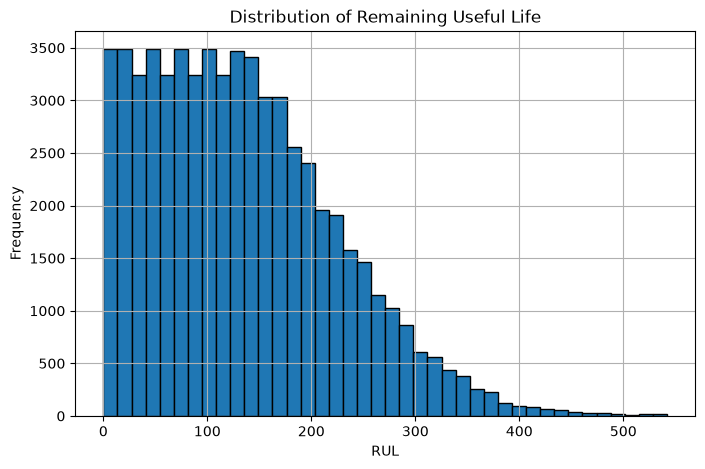

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    eda_df["RUL"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Remaining Useful Life")
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

C:\Users\MF\AppData\Local\Temp\ipykernel_22044\3829589372.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


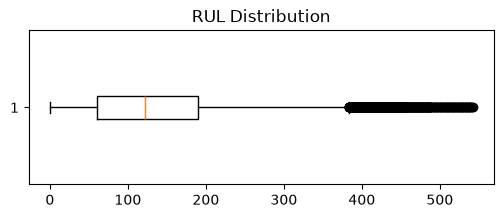

In [8]:
plt.figure(figsize=(6,2))

plt.boxplot(
    eda_df["RUL"],
    vert=False
)

plt.title("RUL Distribution")

plt.show()

In [9]:
bins = [
    0,
    20,
    50,
    100,
    150,
    np.inf
]

labels = [
    "0-20",
    "21-50",
    "51-100",
    "101-150",
    ">150"
]

eda_df["RUL_Group"] = pd.cut(
    eda_df["RUL"],
    bins=bins,
    labels=labels
)

In [10]:
rul_counts = (
    eda_df["RUL_Group"]
    .value_counts()
    .sort_index()
)

rul_counts

RUL_Group
0-20        4980
21-50       7470
51-100     12450
101-150    12349
>150       23751
Name: count, dtype: int64

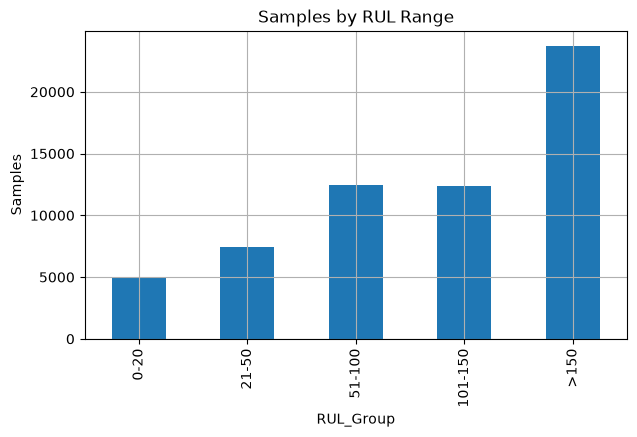

In [11]:
plt.figure(figsize=(7,4))

rul_counts.plot.bar()

plt.title("Samples by RUL Range")
plt.ylabel("Samples")
plt.grid(True)
plt.show()

In [12]:
sample_engines = [1,20,80]

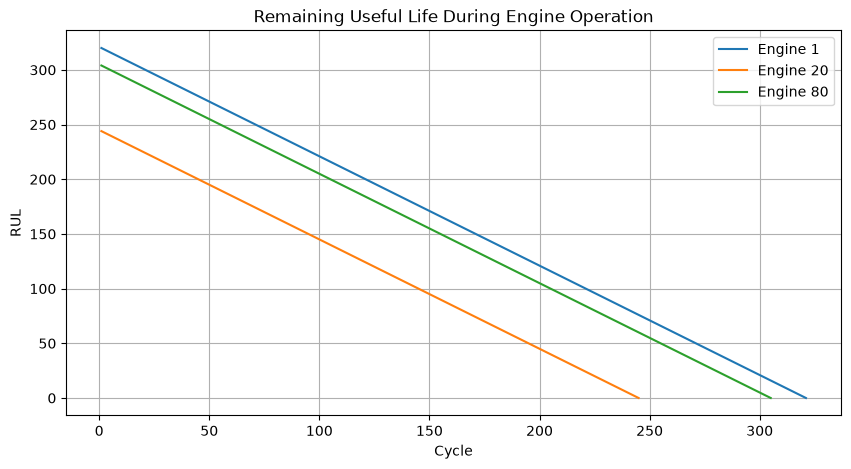

In [13]:
plt.figure(figsize=(10,5))

for engine in sample_engines:

    df = eda_df[
        eda_df.unit_number == engine
    ]

    plt.plot(
        df.time_in_cycles,
        df.RUL,
        label=f"Engine {engine}"
    )

plt.xlabel("Cycle")

plt.ylabel("RUL")

plt.title("Remaining Useful Life During Engine Operation")

plt.legend()

plt.grid(True)

plt.show()

In [14]:
CAP = 125

eda_df["RUL_Capped"] = (
    eda_df["RUL"]
    .clip(upper=CAP)
)

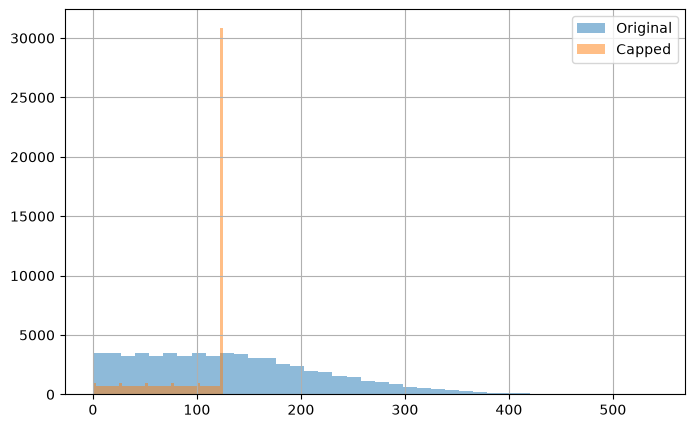

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    eda_df["RUL"],
    bins=40,
    alpha=.5,
    label="Original"
)

plt.hist(
    eda_df["RUL_Capped"],
    bins=40,
    alpha=.5,
    label="Capped"
)

plt.legend()

plt.grid(True)

plt.show()

In [16]:
for threshold in [20,50,100,125]:

    pct = (
        (eda_df["RUL"] > threshold)
        .mean()
        *100
    )

    print(
        f"RUL > {threshold}: {pct:.2f}%"
    )

RUL > 20: 91.46%
RUL > 50: 79.27%
RUL > 100: 58.94%
RUL > 125: 48.78%


In [18]:
summary = pd.DataFrame({
    "Statistic":[
        "Min",
        "Max",
        "Mean",
        "Median",
        "Std"
    ],
    "Value":[
        eda_df.RUL.min(),
        eda_df.RUL.max(),
        eda_df.RUL.mean(),
        eda_df.RUL.median(),
        eda_df.RUL.std()
    ]
})

summary.to_csv(
    "../reports/rul_summary.csv",
    index=False
)

# Observations

## Distribution of Remaining Useful Life (RUL)

The computed Remaining Useful Life (RUL) values exhibit a positively skewed (right-skewed) distribution.

Most observations are concentrated at relatively low RUL values, while the frequency gradually decreases as RUL increases, producing a long right tail extending beyond 500 cycles.

---

## Target Imbalance

The RUL target is clearly imbalanced.

Low and medium RUL values dominate the dataset, whereas very high RUL values occur much less frequently.

The histogram shows that:

- Most samples lie between approximately 0 and 150 cycles.
- Samples with RUL greater than 300 cycles are comparatively rare.
- Very few observations exceed 400 cycles.

Consequently, the dataset contains substantially more information about engines approaching failure than engines in very healthy conditions.

---

## Distribution Across RUL Groups

Grouping the target into intervals further confirms the imbalance.

The majority of observations belong to the highest RUL interval (>150 cycles), while the critical failure region (0–20 cycles) contains considerably fewer samples.

Although the early-failure region represents a minority of the data, it is also the most operationally important for predictive maintenance.

---

## Implications for Predictive Modeling

From a predictive maintenance perspective, distinguishing between engines with very large RUL values (e.g., 250 vs. 450 cycles remaining) is significantly more difficult than distinguishing engines approaching failure.

Healthy engines often exhibit very similar sensor measurements, providing little information for accurately estimating large Remaining Useful Life values.

As degradation progresses, sensor behavior becomes increasingly informative, making accurate prediction more feasible within the later stages of the engine lifecycle.

# Engineering Decisions

## Decision 1 — Adopt RUL Capping

The EDA supports applying an upper cap to the Remaining Useful Life target before model training.

A cap of **125 cycles** will be adopted during preprocessing.

---

## Decision 2 — Preserve Raw RUL During Analysis

The original RUL values will remain unchanged throughout exploratory analysis to preserve the true characteristics of the dataset.

Target capping will be applied only during the preprocessing stage used for model training.

---

## Decision 3 — Focus Model Capacity on the Degradation Region

Predicting very large RUL values provides limited practical value because engines in healthy operating conditions exhibit minimal degradation signals.

Applying a cap allows the learning algorithm to focus on the degradation region, where prediction accuracy is most valuable for maintenance planning.

---

## Decision 4 — Improve Optimization Stability

Without capping, extremely large RUL values dominate the regression loss and encourage the model to spend excessive capacity modeling healthy engines.

Capping compresses the target distribution, resulting in a more balanced optimization problem and reducing the influence of extreme target values.

---

## Decision 5 — Align with Predictive Maintenance Literature

Many published studies using the NASA CMAPSS dataset employ RUL capping (commonly between 125 and 130 cycles).

Adopting the same strategy improves comparability with previous research while reflecting the limited observable degradation during early engine life.